# Week 16 — Wednesday (Jul 10): Point Clouds

## Learning Objectives
- Understand point clouds as unordered sets of 3D points, and how to build one from a calibrated depth map (back-projection)
- Understand why PointNet needs a symmetric aggregation function to be invariant to point order
- Implement PointNet's core building blocks from scratch: shared per-point MLP + max-pool, farthest point sampling, kNN grouping
- Fit a 3D bounding box around an object cluster in a point cloud
- Visualize a real, camera-derived point cloud in 3D

## Key Concepts
1. **Point cloud** — an unordered set `{(x_i, y_i, z_i)}`, unlike an image there is no fixed grid — point `i` and point `j` can be swapped with no change in meaning
2. **Back-projection** — given depth `Z` at pixel `(u,v)` and intrinsics `(f_x,f_y,c_x,c_y)`: `X=(u-c_x)Z/f_x`, `Y=(v-c_y)Z/f_y` — turns a depth map (from LiDAR *or* stereo *or* monocular) into 3D points
3. **Permutation invariance** — a network processing a point cloud must give the same output regardless of the order the points are listed in
4. **PointNet** — applies a shared MLP to every point independently, then a **symmetric** function (max-pool) across all points to get one order-invariant global feature
5. **Farthest Point Sampling (FPS)** — iteratively picks the point farthest from the already-picked set, giving a downsampled set that still covers the object's extent well (used by PointNet++ for hierarchical grouping)
6. **3D bounding box** — axis-aligned (AABB: just min/max per axis) or oriented (OBB) — used in autonomous driving to localise objects (cars, pedestrians) in LiDAR point clouds

## A Note on Tooling
**Open3D has no published wheel for this environment's Python version**, and raw **KITTI Velodyne
`.bin`** point clouds aren't available offline here. Instead of a synthetic point cloud, we
back-project Monday's real, calibrated **Middlebury stereo depth** into 3D — the exact same
back-projection math a LiDAR-fusion or RGB-D pipeline uses — giving a genuine, real-world point
cloud to apply PointNet and 3D bounding-box concepts to. Visualization uses `matplotlib`'s 3D
scatter instead of Open3D's viewer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import warnings
warnings.filterwarnings('ignore')

import cv2
from skimage import data as skdata
from sklearn.cluster import DBSCAN

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
print('Week 16 - Wednesday: Point Clouds')

Week 16 - Wednesday: Point Clouds


## Section 1: Real Point Cloud via Stereo Back-Projection

We recompute Monday's stereo depth (same Middlebury "motorcycle" pair, same `StereoSGBM` +
calibration) and back-project every valid pixel into 3D using the pinhole camera model. Each 3D
point keeps the RGB colour of its source pixel — exactly like a colourised LiDAR scan fused with
a camera image.


In [2]:
# ── Recompute calibrated stereo depth (Monday's pipeline) ─────────────────────
img_left, img_right, disp_gt = skdata.stereo_motorcycle()
gray_l = cv2.cvtColor(img_left, cv2.COLOR_RGB2GRAY)
gray_r = cv2.cvtColor(img_right, cv2.COLOR_RGB2GRAY)

stereo = cv2.StereoSGBM_create(
    minDisparity=0, numDisparities=16*12, blockSize=5,
    P1=8*3*5**2, P2=32*3*5**2, disp12MaxDiff=1, uniquenessRatio=10,
    speckleWindowSize=100, speckleRange=32
)
disp = stereo.compute(gray_l, gray_r).astype(np.float32) / 16.0
disp[disp <= 0] = np.nan

FOCAL_PX, BASELINE_MM = 994.978, 193.001
CX, CY = 311.193, 254.877   # principal point (px), per Middlebury 2014 calibration
with np.errstate(divide='ignore', invalid='ignore'):
    depth_mm = (FOCAL_PX * BASELINE_MM) / disp
depth_m = depth_mm / 1000.0
print(f'Depth map: {depth_m.shape} | valid pixels: {np.sum(~np.isnan(depth_m)):,}')

Depth map: (500, 741) | valid pixels: 261,530


Back-projected point cloud: 255,798 points
Subsampled to 15,000 points for visualisation/processing


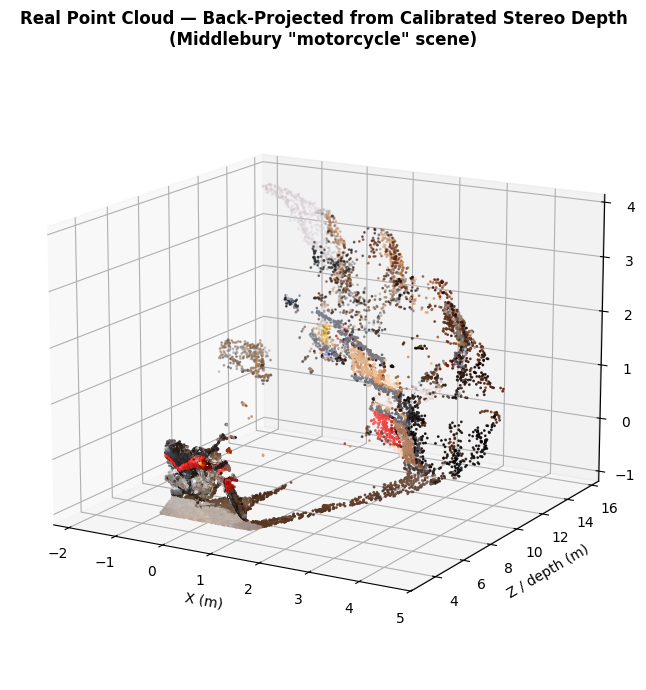

Saved point_cloud_3d.png


In [3]:
# ── Back-project to 3D: (u,v,Z) -> (X,Y,Z) via pinhole intrinsics ─────────────
H, W = depth_m.shape
us, vs = np.meshgrid(np.arange(W), np.arange(H))
Z = depth_m
X = (us - CX) * Z / FOCAL_PX
Y = (vs - CY) * Z / FOCAL_PX

valid = ~np.isnan(Z) & (Z > 0) & (Z < np.nanpercentile(Z, 98))   # drop far/invalid outliers
points = np.stack([X[valid], Y[valid], Z[valid]], axis=1)
colors = img_left[valid].astype(np.float32) / 255.0
print(f'Back-projected point cloud: {len(points):,} points')

# Subsample for fast plotting/processing
N_KEEP = 15000
idx = np.random.choice(len(points), min(N_KEEP, len(points)), replace=False)
points, colors = points[idx], colors[idx]
print(f'Subsampled to {len(points):,} points for visualisation/processing')

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,2], -points[:,1], c=colors, s=1)
ax.set_xlabel('X (m)'); ax.set_ylabel('Z / depth (m)'); ax.set_zlabel('-Y (m)')
ax.set_title('Real Point Cloud — Back-Projected from Calibrated Stereo Depth\n'
             '(Middlebury "motorcycle" scene)', fontweight='bold')
ax.view_init(elev=15, azim=-60)
plt.tight_layout()
plt.savefig('point_cloud_3d.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved point_cloud_3d.png')

## Section 2: Farthest Point Sampling (FPS)

Dense point clouds (tens of thousands of points) are too expensive to process directly with most
networks. **FPS** downsamples while preserving the object's overall shape: start from a random
point, then repeatedly add whichever remaining point is **farthest from the current sampled set**
(measured as the minimum distance to any already-picked point) — this spreads samples evenly
across the whole structure instead of clustering them in dense regions.


FPS: 15,000 points -> 512 samples


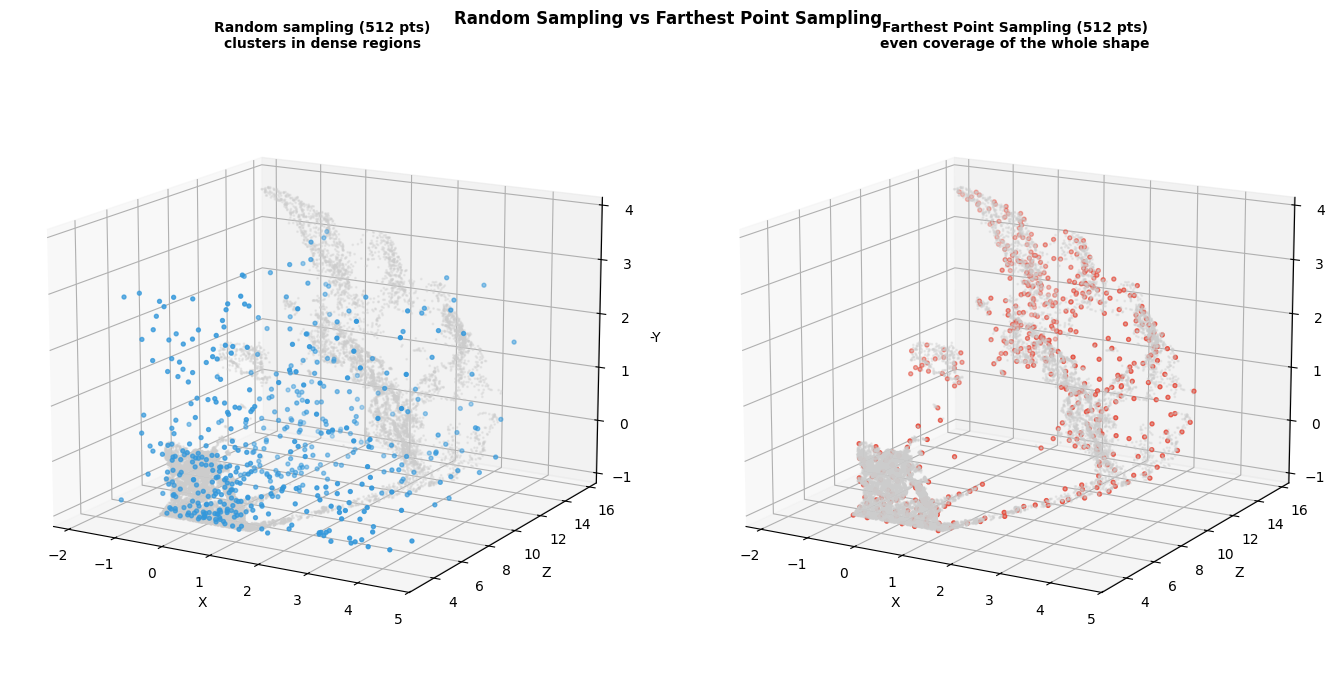

Saved fps_sampling.png


In [4]:
# ── Farthest Point Sampling from scratch ───────────────────────────────────────
def farthest_point_sampling(pts, n_samples, seed=0):
    rng = np.random.RandomState(seed)
    N = pts.shape[0]
    sampled_idx = np.zeros(n_samples, dtype=np.int64)
    sampled_idx[0] = rng.randint(N)
    min_dist = np.full(N, np.inf)
    for i in range(1, n_samples):
        last = pts[sampled_idx[i-1]]
        dist = np.sum((pts - last)**2, axis=1)
        min_dist = np.minimum(min_dist, dist)
        sampled_idx[i] = np.argmax(min_dist)
    return sampled_idx

N_FPS = 512
fps_idx = farthest_point_sampling(points, N_FPS)
fps_points, fps_colors = points[fps_idx], colors[fps_idx]
print(f'FPS: {len(points):,} points -> {N_FPS} samples')

fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points[:,0], points[:,2], -points[:,1], c='#cccccc', s=1, alpha=0.3)
ax1.scatter(points[np.random.choice(len(points), N_FPS, replace=False), 0],
            points[np.random.choice(len(points), N_FPS, replace=False), 2],
            -points[np.random.choice(len(points), N_FPS, replace=False), 1],
            c='#3498db', s=8)
ax1.set_title(f'Random sampling ({N_FPS} pts)\nclusters in dense regions', fontsize=10, fontweight='bold')
ax1.view_init(elev=15, azim=-60); ax1.set_xlabel('X'); ax1.set_ylabel('Z'); ax1.set_zlabel('-Y')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points[:,0], points[:,2], -points[:,1], c='#cccccc', s=1, alpha=0.3)
ax2.scatter(fps_points[:,0], fps_points[:,2], -fps_points[:,1], c='#e74c3c', s=8)
ax2.set_title(f'Farthest Point Sampling ({N_FPS} pts)\neven coverage of the whole shape', fontsize=10, fontweight='bold')
ax2.view_init(elev=15, azim=-60); ax2.set_xlabel('X'); ax2.set_ylabel('Z'); ax2.set_zlabel('-Y')

plt.suptitle('Random Sampling vs Farthest Point Sampling', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fps_sampling.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fps_sampling.png')

## Section 3: kNN Local Grouping

PointNet++ builds hierarchical features by grouping each FPS-sampled **centroid** with its
`k` nearest neighbours, then running a mini-PointNet on each local group. Below we visualise one
such local neighbourhood.


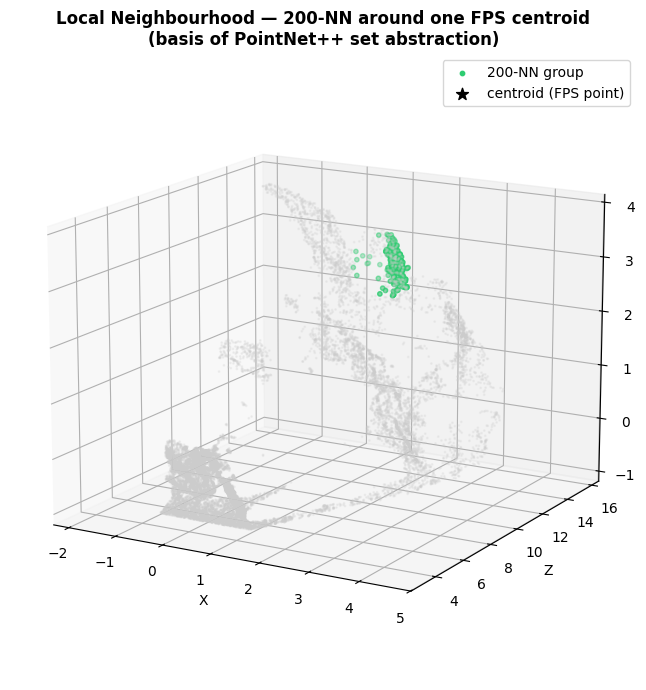

Saved knn_grouping.png


In [5]:
# ── kNN grouping around one FPS centroid ───────────────────────────────────────
def knn_group(pts, centroid_idx, k):
    centroid = pts[centroid_idx]
    dist = np.sum((pts - centroid)**2, axis=1)
    return np.argsort(dist)[:k]

K = 200
centroid_idx = fps_idx[N_FPS // 2]
group_idx = knn_group(points, centroid_idx, K)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,2], -points[:,1], c='#cccccc', s=1, alpha=0.2)
ax.scatter(points[group_idx,0], points[group_idx,2], -points[group_idx,1], c='#2ecc71', s=10, label=f'{K}-NN group')
ax.scatter(*[[points[centroid_idx,0]], [points[centroid_idx,2]], [-points[centroid_idx,1]]],
           c='black', s=80, marker='*', label='centroid (FPS point)')
ax.set_title(f'Local Neighbourhood — {K}-NN around one FPS centroid\n(basis of PointNet++ set abstraction)',
             fontweight='bold')
ax.legend(); ax.view_init(elev=15, azim=-60); ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('-Y')
plt.tight_layout()
plt.savefig('knn_grouping.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved knn_grouping.png')

## Section 4: PointNet — Shared MLP + Symmetric Max-Pool

A point cloud has no canonical order, so a network processing it must be **permutation
invariant**: shuffling the input points must not change the output. PointNet achieves this with a
per-point shared MLP followed by a symmetric aggregation function (element-wise max over all
points) — max-pooling doesn't care what order its inputs arrive in.


In [6]:
# ── Tiny PointNet feature extractor (shared MLP + global max-pool) ────────────
import torch
import torch.nn as nn

class TinyPointNet(nn.Module):
    def __init__(self, in_ch=3, feat_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(in_ch, 64, 1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, feat_dim, 1)
        )

    def forward(self, x):
        # x: (B, N, 3) -> per-point MLP -> (B, feat_dim, N) -> global max-pool -> (B, feat_dim)
        x = x.transpose(1, 2)              # (B, 3, N)
        point_feats = self.mlp(x)          # (B, feat_dim, N)
        global_feat, _ = point_feats.max(dim=2)   # symmetric aggregation
        return global_feat

pointnet = TinyPointNet().eval()
pts_batch = torch.tensor(fps_points, dtype=torch.float32).unsqueeze(0)   # (1, N_FPS, 3)

with torch.no_grad():
    feat_original = pointnet(pts_batch)
    perm = torch.randperm(pts_batch.shape[1])
    feat_shuffled = pointnet(pts_batch[:, perm, :])

max_abs_diff = (feat_original - feat_shuffled).abs().max().item()
print(f'TinyPointNet params: {sum(p.numel() for p in pointnet.parameters()):,}')
print(f'Global feature — original order vs shuffled order — max abs diff: {max_abs_diff:.2e}')
print('-> confirms permutation invariance: reordering the input points does not change the output')

TinyPointNet params: 41,984
Global feature — original order vs shuffled order — max abs diff: 0.00e+00
-> confirms permutation invariance: reordering the input points does not change the output


## Section 5: 3D Bounding Box — Segmenting and Localising an Object

To localise an object in the point cloud (as a 3D object detector would for a car or pedestrian in
LiDAR data), we cluster the near-camera points with **DBSCAN** — a density-based clustering
algorithm that doesn't need the number of clusters specified up front and naturally separates the
foreground object from scattered background points. The largest cluster is then wrapped in an
axis-aligned bounding box (AABB).


DBSCAN found 19 clusters in the near-field points
Largest cluster: 4,401 points
3D bounding box  min=[-0.468 -0.556  3.262]  max=[1.588 0.842 3.985]  (metres)


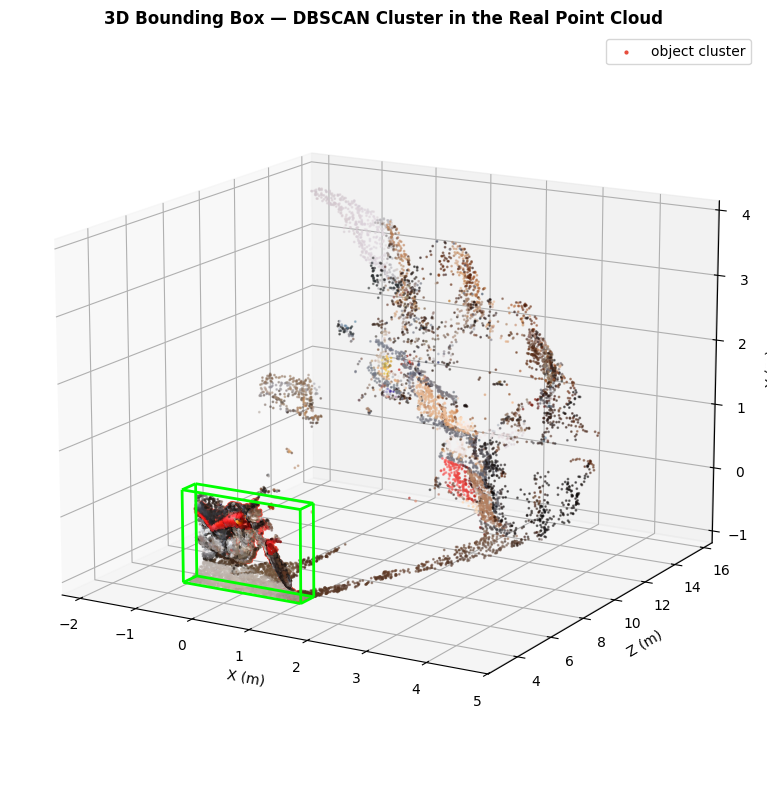

Saved point_cloud_bbox.png


In [7]:
# ── Cluster the foreground (near-camera points) and fit an AABB ────────────────
near_mask = points[:,2] < np.percentile(points[:,2], 40)   # nearest 40% of points by depth
near_points = points[near_mask]

db = DBSCAN(eps=0.06, min_samples=15).fit(near_points)
labels = db.labels_
valid_labels = labels[labels >= 0]
largest_cluster = np.bincount(valid_labels).argmax()
cluster_pts = near_points[labels == largest_cluster]

box_min, box_max = cluster_pts.min(axis=0), cluster_pts.max(axis=0)
print(f'DBSCAN found {valid_labels.max()+1} clusters in the near-field points')
print(f'Largest cluster: {len(cluster_pts):,} points')
print(f'3D bounding box  min={np.round(box_min,3)}  max={np.round(box_max,3)}  (metres)')

def box_edges(bmin, bmax):
    x0,y0,z0 = bmin; x1,y1,z1 = bmax
    corners = np.array([[x0,y0,z0],[x1,y0,z0],[x1,y1,z0],[x0,y1,z0],
                         [x0,y0,z1],[x1,y0,z1],[x1,y1,z1],[x0,y1,z1]])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    return [[corners[i], corners[j]] for i,j in edges]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,2], -points[:,1], c=colors, s=1, alpha=0.5)
ax.scatter(cluster_pts[:,0], cluster_pts[:,2], -cluster_pts[:,1], c='#e74c3c', s=4, label='object cluster')
lines = [[(p[0], p[2], -p[1]) for p in edge] for edge in box_edges(box_min, box_max)]
ax.add_collection3d(Line3DCollection(lines, colors='lime', linewidths=2))
ax.set_title('3D Bounding Box — DBSCAN Cluster in the Real Point Cloud', fontweight='bold')
ax.legend(); ax.view_init(elev=15, azim=-60); ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)'); ax.set_zlabel('-Y (m)')
plt.tight_layout()
plt.savefig('point_cloud_bbox.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved point_cloud_bbox.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Back-projection** | `X=(u-c_x)Z/f_x, Y=(v-c_y)Z/f_y` turns any depth map — LiDAR, stereo, or monocular — into a 3D point cloud |
| **Permutation invariance** | Point clouds have no fixed order — verified empirically: shuffling `TinyPointNet`'s input points left its global feature unchanged |
| **PointNet's trick** | Per-point shared MLP + symmetric max-pool — the max-pool is what makes the whole network order-invariant |
| **FPS** | Iteratively picks the farthest remaining point from the current sample set — spreads samples evenly, unlike random sampling |
| **kNN grouping** | Each FPS centroid + its `k` nearest neighbours forms a local region — the basis of PointNet++'s hierarchical set abstraction |
| **3D bounding box** | DBSCAN clustering + per-axis min/max on a real cluster localises an object in 3D, the same shape as a LiDAR 3D-detector's output |
